# ResNet18-based model with the RadioML 2018A dataset + LoRa

In [10]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [11]:
from src.dataset import *
from src.utils import *
from src.config import setup_environment

In [12]:
GLOBAL_SEED = 2026
setup_environment(seed=GLOBAL_SEED)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
path = "/home/wicom/Descargas/" # adjust yours
file = "RadioML2018_plus_LoRa_train.h5"
classes = RadioMLConfig.CLASSES + LoRaConfig.CLASSES
#fs = RadioMLConfig.FS
X_train, Y_train, Z_train = load_dataset(path, file)

[INFO] Loading /home/wicom/Descargas/RadioML2018_plus_LoRa_train.h5 ...
[INFO] Loaded Dataset | X:(2555904, 1024, 2) Y:(2555904, 30) Z:(2555904, 1) | dtype X:float32


In [14]:
path = "/home/wicom/Descargas/" # adjust yours
file = "RadioML2018_plus_LoRa_val.h5"
classes = RadioMLConfig.CLASSES + LoRaConfig.CLASSES
#fs = RadioMLConfig.FS
X_val, Y_val, Z_val = load_dataset(path, file)

[INFO] Loading /home/wicom/Descargas/RadioML2018_plus_LoRa_val.h5 ...
[INFO] Loaded Dataset | X:(319488, 1024, 2) Y:(319488, 30) Z:(319488, 1) | dtype X:float32


In [15]:
path = "/home/wicom/Descargas/" # adjust yours
file = "RadioML2018_plus_LoRa_test.h5"
classes = RadioMLConfig.CLASSES + LoRaConfig.CLASSES
#fs = RadioMLConfig.FS
X_test, Y_test, Z_test = load_dataset(path, file)

[INFO] Loading /home/wicom/Descargas/RadioML2018_plus_LoRa_test.h5 ...
[INFO] Loaded Dataset | X:(319488, 1024, 2) Y:(319488, 30) Z:(319488, 1) | dtype X:float32


In [16]:
# using PyDataset
BATCH_SIZE = 256
train_ds = PyDataset(X_train, Y_train, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = PyDataset(X_val,   Y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = PyDataset(X_test,  Y_test,  batch_size=BATCH_SIZE, shuffle=False)

print("[INFO] PyDataset ok!")

[INFO] PyDataset ok!


In [17]:
from src.models.resnet18 import build_resnet_model
from src.evaluate import PlotLosses

In [18]:
plot_losses = PlotLosses()

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
from src.train import lr_search
parameters_dict = {
    "input_shape": (1024, 2),
    "num_classes": 30,
    "name": "resnet18_radioml2018_plus_lora",
    "use_se": False
}
lr_candidates = [1e-4, 3e-4, 1e-3, 3e-3]
best_lr = lr_search(lr_candidates, train_ds, val_ds, build_resnet_model, parameters_dict, 
                    epochs_per_trial=3, seed=GLOBAL_SEED)
# in this case: best_lr = 0.001


[INFO] Testing LR = 1.0e-04
Epoch 1/3
9984/9984 ━━━━━━━━━━━━━━━━━━━━ 173s 17ms/step - accuracy: 0.3626 - loss: 1.8520 - val_accuracy: 0.4430 - val_loss: 1.6229
Epoch 2/3
9984/9984 ━━━━━━━━━━━━━━━━━━━━ 167s 17ms/step - accuracy: 0.4717 - loss: 1.5190 - val_accuracy: 0.4941 - val_loss: 1.4727
Epoch 3/3
9984/9984 ━━━━━━━━━━━━━━━━━━━━ 167s 17ms/step - accuracy: 0.5252 - loss: 1.3822 - val_accuracy: 0.5472 - val_loss: 1.3380
[RESULT] LR=1.0e-04  best_val_loss=1.337984

[INFO] Testing LR = 3.0e-04
Epoch 1/3
9984/9984 ━━━━━━━━━━━━━━━━━━━━ 173s 17ms/step - accuracy: 0.4288 - loss: 1.6487 - val_accuracy: 0.5225 - val_loss: 1.3905
Epoch 2/3
9984/9984 ━━━━━━━━━━━━━━━━━━━━ 168s 17ms/step - accuracy: 0.5483 - loss: 1.3209 - val_accuracy: 0.5844 - val_loss: 1.2273
Epoch 3/3
9984/9984 ━━━━━━━━━━━━━━━━━━━━ 168s 17ms/step - accuracy: 0.5811 - loss: 1.2412 - val_accuracy: 0.6025 - val_loss: 1.1803
[RESULT] LR=3.0e-04  best_val_loss=1.180299

[INFO] Testing LR = 1.0e-03
Epoch 1/3
9984/9984 ━━━━━━━━━━━━━

In [21]:
from src.train import compile_model_with_lr
model = build_resnet_model(parameters_dict)
model = compile_model_with_lr(model, best_lr) 
model.summary()

Model: "resnet18_radioml2018_plus_lora"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1024, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 512, 32)   │        960 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 256, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 32)   │      3,072 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 32)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 32)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 32)   │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 256, 32)   │      3,072 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 256, 32)   │      3,072 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 32)   │          0 │ batch_normalizat

 Total params: 976,734 (3.73 MB)

 Trainable params: 971,934 (3.71 MB)

 Non-trainable params: 4,800 (18.75 KB)

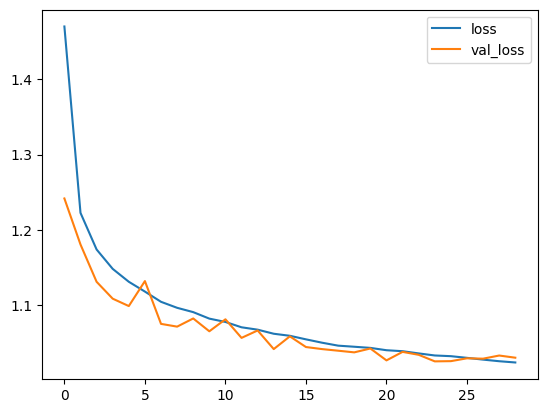

9984/9984 - 165s - 17ms/step - accuracy: 0.6666 - loss: 1.0235 - val_accuracy: 0.6642 - val_loss: 1.0298 - learning_rate: 6.8630e-04

Training finished in 4809.00 seconds


In [22]:
from src.train import train_model
EPOCHS = 100
history, training_time = train_model(model=model, 
                                     train_ds=train_ds, 
                                     val_ds=val_ds,
                                     epochs=EPOCHS,
                                     plot_callback=plot_losses)

In [ ]:
import pandas as pd
history_dict = pd.DataFrame(history.history)
display(history_dict)
history_dict.to_csv("./training_history_ResNet18_RadioML2018_plus_LoRa.csv", index=False)

In [34]:
print("Save Model...", flush=True)
model.save("./Resnet18_1024_RadioML2018_plus_LoRa.keras")

Save Model...


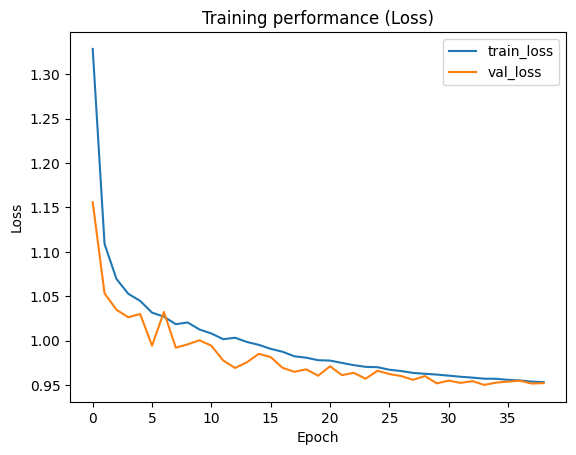

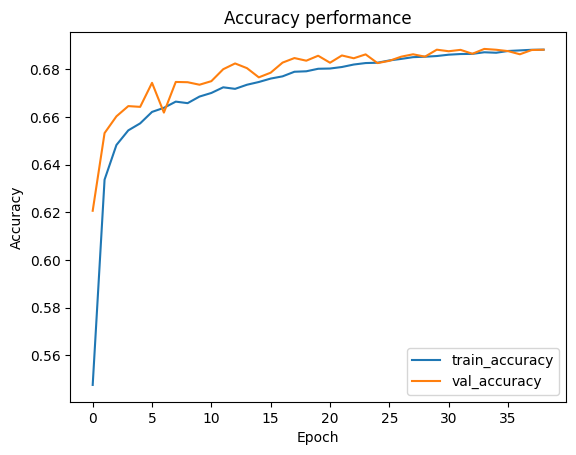

In [35]:
from src.evaluate import plot_loss, plot_accuracy

plot_loss(history)
plot_accuracy(history)

In [26]:
### TEST

1248/1248 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6661 - loss: 1.0239
Test loss: 1.023921012878418
Test accuracy: 0.6660938858985901
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


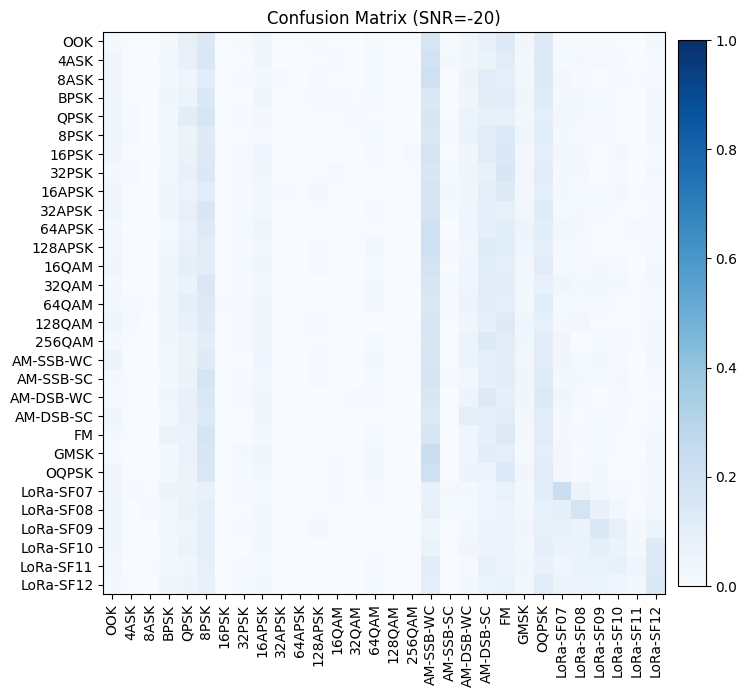

Classification Report for SNR -20 dB
              precision    recall  f1-score   support

         OOK       0.02      0.02      0.02       410
        4ASK       0.04      0.01      0.01       409
        8ASK       0.00      0.00      0.00       410
        BPSK       0.04      0.04      0.04       409
        QPSK       0.05      0.10      0.07       409
        8PSK       0.03      0.12      0.05       410
       16PSK       0.00      0.00      0.00       410
       32PSK       0.04      0.01      0.02       410
      16APSK       0.03      0.03      0.03       410
      32APSK       0.00      0.00      0.00       409
      64APSK       0.07      0.00      0.01       409
     128APSK       0.06      0.01      0.02       410
       16QAM       0.01      0.00      0.00       410
       32QAM       0.02      0.00      0.00       410
       64QAM       0.06      0.02      0.03       410
      128QAM       0.00      0.00      0.00       410
      256QAM       0.08      0.01      0.01 

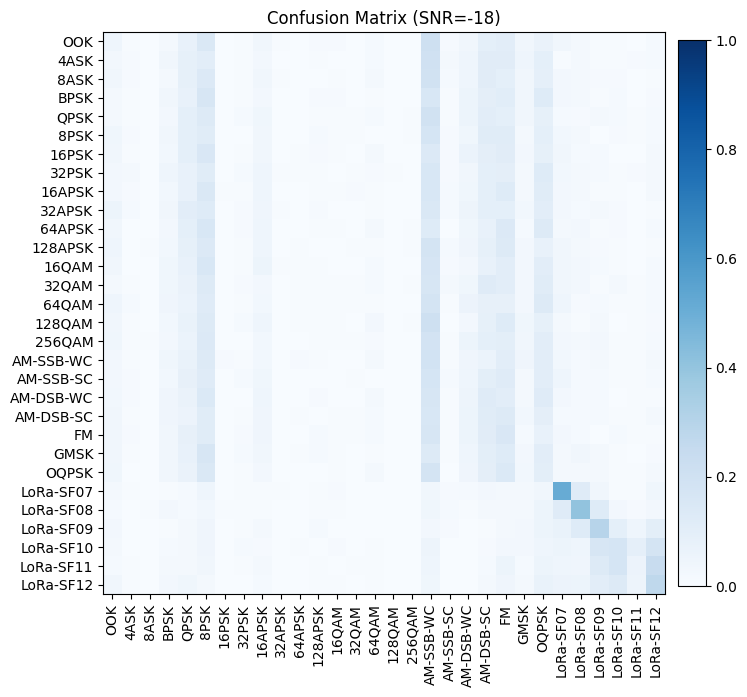

Classification Report for SNR -18 dB
              precision    recall  f1-score   support

         OOK       0.05      0.05      0.05       410
        4ASK       0.05      0.01      0.02       409
        8ASK       0.00      0.00      0.00       410
        BPSK       0.04      0.03      0.03       410
        QPSK       0.05      0.09      0.06       410
        8PSK       0.03      0.12      0.05       410
       16PSK       0.07      0.00      0.00       409
       32PSK       0.06      0.01      0.02       410
      16APSK       0.05      0.04      0.04       410
      32APSK       0.07      0.00      0.01       409
      64APSK       0.00      0.00      0.00       410
     128APSK       0.01      0.00      0.00       409
       16QAM       0.00      0.00      0.00       410
       32QAM       0.05      0.00      0.01       410
       64QAM       0.02      0.01      0.01       410
      128QAM       0.00      0.00      0.00       410
      256QAM       0.03      0.00      0.00 

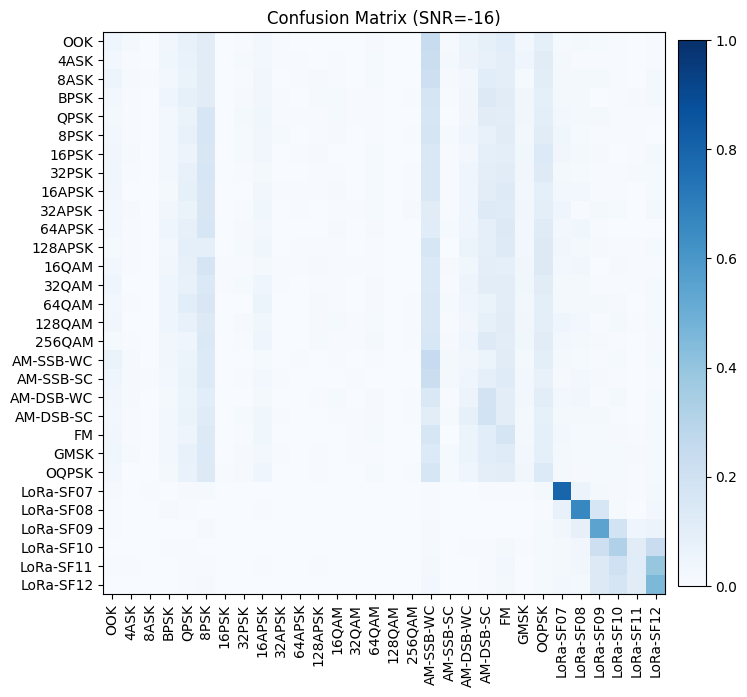

Classification Report for SNR -16 dB
              precision    recall  f1-score   support

         OOK       0.06      0.05      0.05       409
        4ASK       0.02      0.00      0.01       410
        8ASK       0.11      0.00      0.01       410
        BPSK       0.05      0.04      0.04       409
        QPSK       0.04      0.06      0.05       410
        8PSK       0.05      0.16      0.07       410
       16PSK       0.07      0.00      0.00       410
       32PSK       0.03      0.01      0.01       409
      16APSK       0.04      0.03      0.04       409
      32APSK       0.00      0.00      0.00       409
      64APSK       0.00      0.00      0.00       410
     128APSK       0.03      0.00      0.01       409
       16QAM       0.03      0.00      0.01       409
       32QAM       0.00      0.00      0.00       409
       64QAM       0.04      0.01      0.02       410
      128QAM       0.00      0.00      0.00       410
      256QAM       0.07      0.00      0.01 

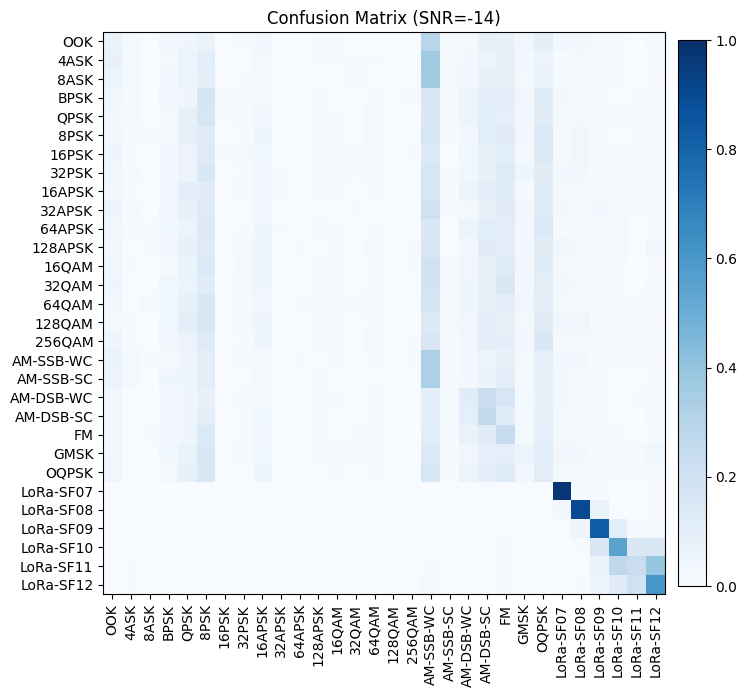

Classification Report for SNR -14 dB
              precision    recall  f1-score   support

         OOK       0.07      0.07      0.07       410
        4ASK       0.06      0.01      0.02       410
        8ASK       0.00      0.00      0.00       410
        BPSK       0.05      0.03      0.04       410
        QPSK       0.05      0.08      0.06       410
        8PSK       0.04      0.11      0.06       409
       16PSK       0.23      0.01      0.02       410
       32PSK       0.03      0.01      0.01       409
      16APSK       0.04      0.03      0.04       410
      32APSK       0.00      0.00      0.00       409
      64APSK       0.00      0.00      0.00       410
     128APSK       0.02      0.00      0.00       410
       16QAM       0.04      0.01      0.01       409
       32QAM       0.03      0.00      0.00       410
       64QAM       0.06      0.01      0.02       410
      128QAM       0.00      0.00      0.00       410
      256QAM       0.08      0.00      0.01 

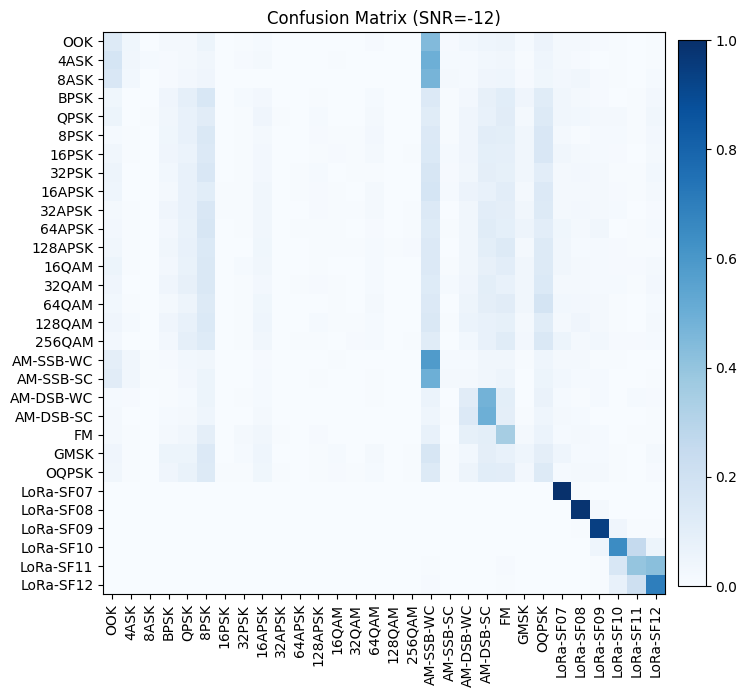

Classification Report for SNR -12 dB
              precision    recall  f1-score   support

         OOK       0.10      0.13      0.11       410
        4ASK       0.13      0.03      0.05       410
        8ASK       0.00      0.00      0.00       409
        BPSK       0.06      0.04      0.05       409
        QPSK       0.06      0.08      0.06       410
        8PSK       0.06      0.15      0.08       410
       16PSK       0.07      0.00      0.00       409
       32PSK       0.03      0.00      0.01       409
      16APSK       0.05      0.03      0.04       410
      32APSK       0.06      0.00      0.00       410
      64APSK       0.14      0.01      0.01       410
     128APSK       0.05      0.01      0.01       409
       16QAM       0.02      0.00      0.00       410
       32QAM       0.03      0.00      0.00       409
       64QAM       0.07      0.02      0.03       410
      128QAM       0.00      0.00      0.00       409
      256QAM       0.09      0.00      0.01 

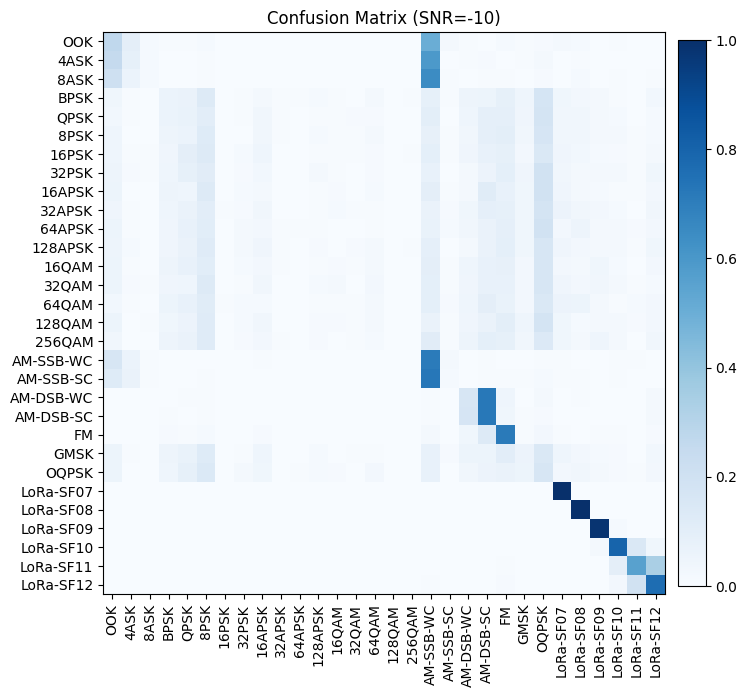

Classification Report for SNR -10 dB
              precision    recall  f1-score   support

         OOK       0.15      0.27      0.19       410
        4ASK       0.18      0.09      0.12       410
        8ASK       0.19      0.01      0.03       410
        BPSK       0.08      0.06      0.07       409
        QPSK       0.06      0.07      0.06       409
        8PSK       0.06      0.12      0.08       410
       16PSK       0.10      0.00      0.00       409
       32PSK       0.05      0.01      0.02       410
      16APSK       0.03      0.02      0.02       410
      32APSK       0.00      0.00      0.00       409
      64APSK       0.23      0.01      0.01       409
     128APSK       0.06      0.01      0.02       409
       16QAM       0.09      0.01      0.02       410
       32QAM       0.03      0.00      0.00       410
       64QAM       0.09      0.02      0.04       410
      128QAM       0.00      0.00      0.00       410
      256QAM       0.00      0.00      0.00 

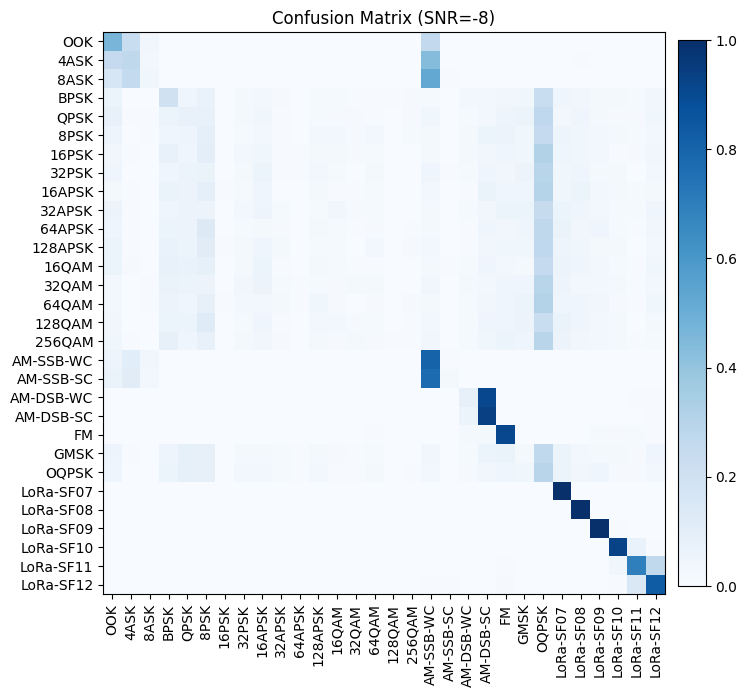

Classification Report for SNR -8 dB
              precision    recall  f1-score   support

         OOK       0.27      0.47      0.35       410
        4ASK       0.26      0.27      0.27       410
        8ASK       0.20      0.04      0.07       410
        BPSK       0.18      0.20      0.19       410
        QPSK       0.08      0.07      0.07       410
        8PSK       0.07      0.09      0.08       410
       16PSK       0.06      0.00      0.00       410
       32PSK       0.06      0.02      0.03       410
      16APSK       0.08      0.05      0.06       410
      32APSK       0.08      0.01      0.02       410
      64APSK       0.05      0.00      0.00       410
     128APSK       0.04      0.01      0.02       410
       16QAM       0.06      0.01      0.02       410
       32QAM       0.14      0.02      0.03       409
       64QAM       0.04      0.01      0.02       410
      128QAM       0.14      0.00      0.00       409
      256QAM       0.06      0.00      0.01  

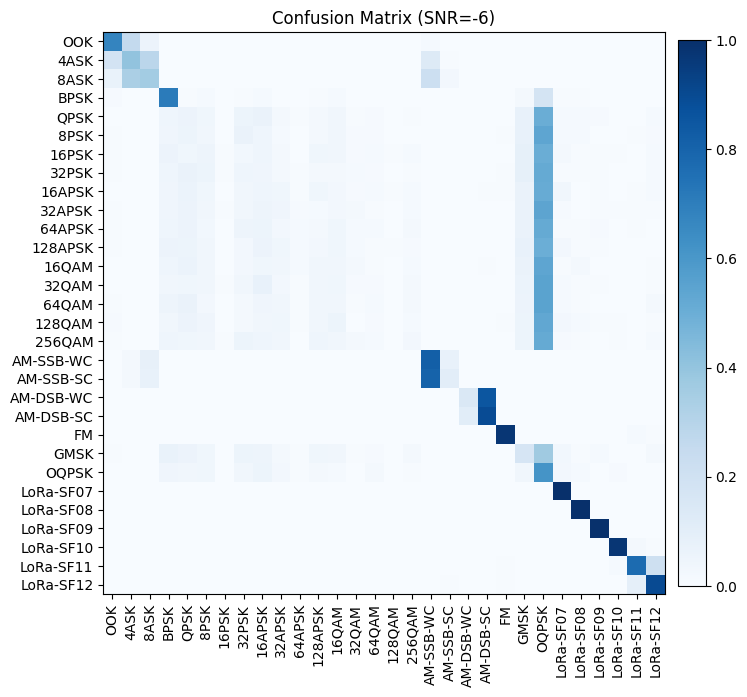

Classification Report for SNR -6 dB
              precision    recall  f1-score   support

         OOK       0.68      0.68      0.68       410
        4ASK       0.39      0.40      0.40       410
        8ASK       0.42      0.36      0.38       409
        BPSK       0.51      0.71      0.59       410
        QPSK       0.07      0.06      0.06       409
        8PSK       0.06      0.03      0.04       409
       16PSK       0.13      0.00      0.01       410
       32PSK       0.08      0.05      0.06       410
      16APSK       0.06      0.04      0.05       409
      32APSK       0.09      0.04      0.06       409
      64APSK       0.14      0.01      0.03       410
     128APSK       0.06      0.03      0.04       410
       16QAM       0.07      0.03      0.05       410
       32QAM       0.06      0.01      0.02       409
       64QAM       0.08      0.01      0.02       410
      128QAM       0.00      0.00      0.00       410
      256QAM       0.12      0.02      0.04  

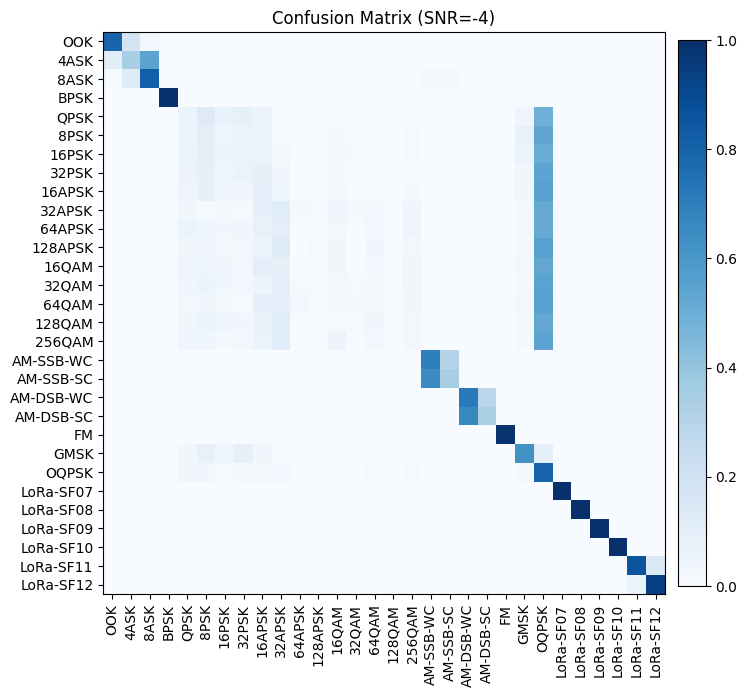

Classification Report for SNR -4 dB
              precision    recall  f1-score   support

         OOK       0.87      0.80      0.83       410
        4ASK       0.54      0.35      0.42       410
        8ASK       0.58      0.82      0.68       409
        BPSK       0.97      1.00      0.98       409
        QPSK       0.09      0.06      0.07       409
        8PSK       0.10      0.10      0.10       410
       16PSK       0.10      0.05      0.07       410
       32PSK       0.10      0.06      0.08       409
      16APSK       0.09      0.10      0.09       409
      32APSK       0.12      0.11      0.12       409
      64APSK       0.06      0.01      0.01       410
     128APSK       0.16      0.01      0.02       410
       16QAM       0.10      0.04      0.05       409
       32QAM       0.09      0.01      0.02       409
       64QAM       0.09      0.02      0.04       410
      128QAM       0.24      0.01      0.02       409
      256QAM       0.07      0.02      0.04  

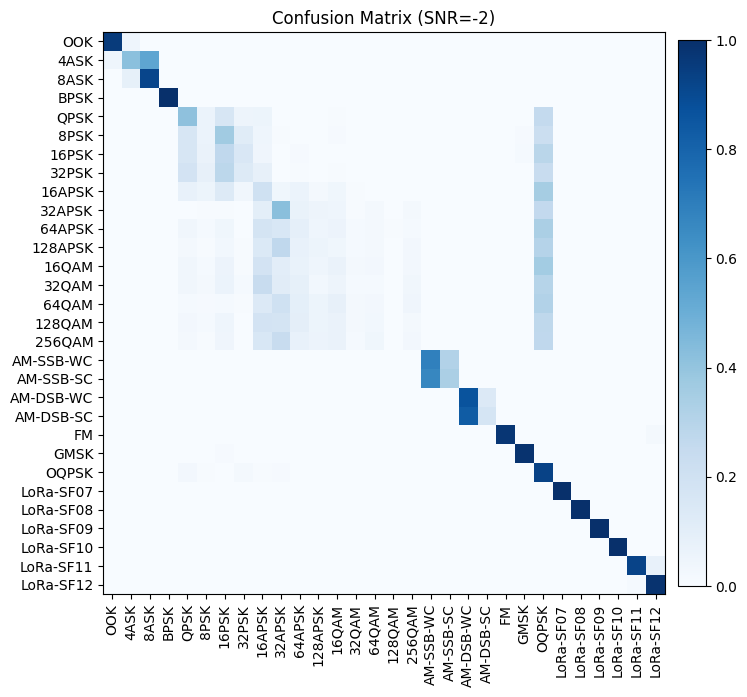

Classification Report for SNR -2 dB
              precision    recall  f1-score   support

         OOK       0.96      0.95      0.95       410
        4ASK       0.76      0.42      0.54       409
        8ASK       0.63      0.91      0.75       410
        BPSK       1.00      1.00      1.00       409
        QPSK       0.34      0.41      0.37       409
        8PSK       0.15      0.06      0.09       409
       16PSK       0.18      0.27      0.21       410
       32PSK       0.24      0.13      0.17       409
      16APSK       0.12      0.20      0.15       410
      32APSK       0.25      0.43      0.31       409
      64APSK       0.12      0.09      0.10       410
     128APSK       0.13      0.05      0.07       409
       16QAM       0.12      0.06      0.08       410
       32QAM       0.12      0.01      0.03       410
       64QAM       0.14      0.03      0.04       410
      128QAM       0.14      0.00      0.00       410
      256QAM       0.13      0.03      0.04  

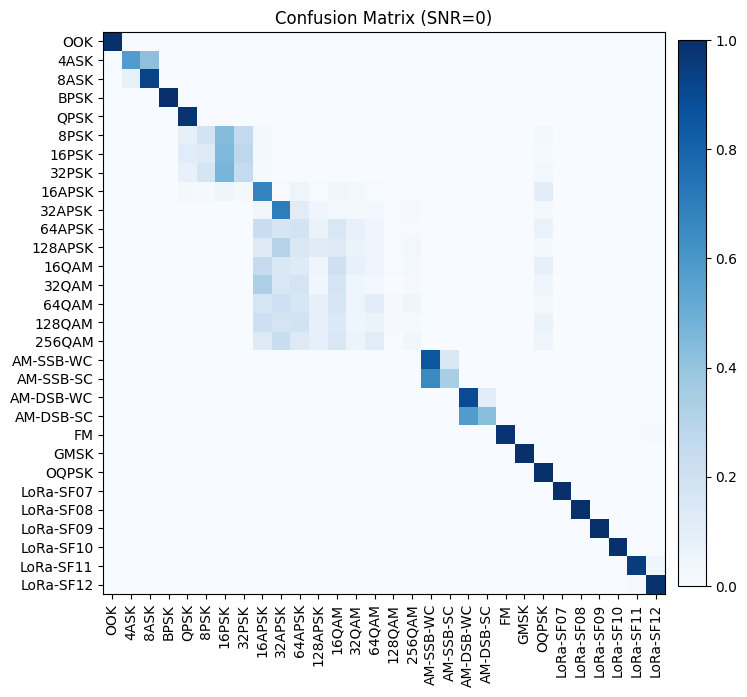

Classification Report for SNR 0 dB
              precision    recall  f1-score   support

         OOK       0.99      1.00      1.00       410
        4ASK       0.88      0.58      0.70       409
        8ASK       0.69      0.92      0.79       410
        BPSK       1.00      1.00      1.00       409
        QPSK       0.77      0.98      0.86       410
        8PSK       0.36      0.18      0.24       410
       16PSK       0.32      0.45      0.37       409
       32PSK       0.31      0.25      0.27       409
      16APSK       0.31      0.67      0.42       410
      32APSK       0.34      0.70      0.45       410
      64APSK       0.14      0.18      0.16       410
     128APSK       0.21      0.12      0.15       410
       16QAM       0.18      0.21      0.19       410
       32QAM       0.10      0.05      0.06       410
       64QAM       0.21      0.11      0.14       409
      128QAM       0.20      0.01      0.02       410
      256QAM       0.23      0.04      0.07   

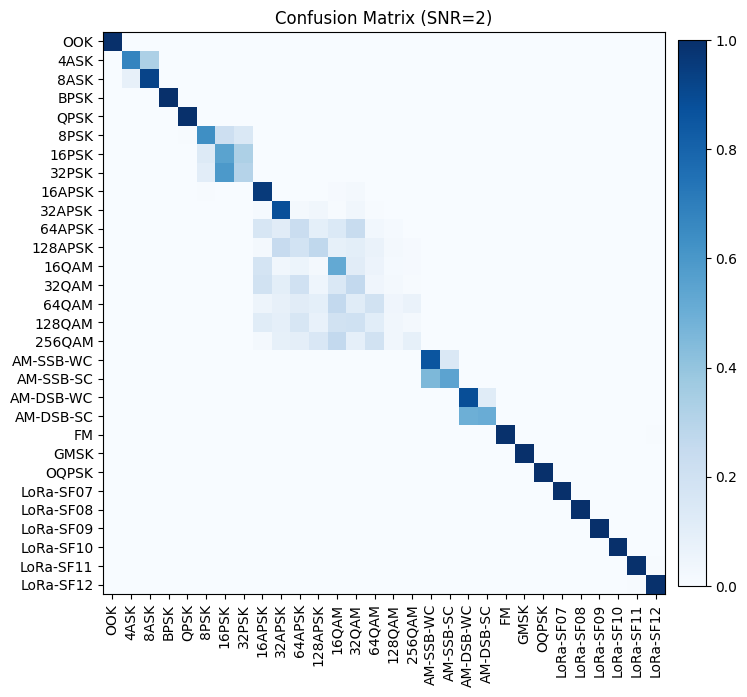

Classification Report for SNR 2 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       409
        4ASK       0.89      0.67      0.77       410
        8ASK       0.74      0.92      0.82       410
        BPSK       1.00      1.00      1.00       409
        QPSK       1.00      1.00      1.00       409
        8PSK       0.73      0.64      0.68       409
       16PSK       0.40      0.55      0.47       410
       32PSK       0.39      0.30      0.34       410
      16APSK       0.56      0.96      0.71       409
      32APSK       0.54      0.88      0.67       409
      64APSK       0.22      0.23      0.22       409
     128APSK       0.34      0.27      0.30       409
       16QAM       0.32      0.52      0.40       410
       32QAM       0.22      0.26      0.24       410
       64QAM       0.28      0.19      0.22       409
      128QAM       0.19      0.03      0.05       410
      256QAM       0.43      0.08      0.14   

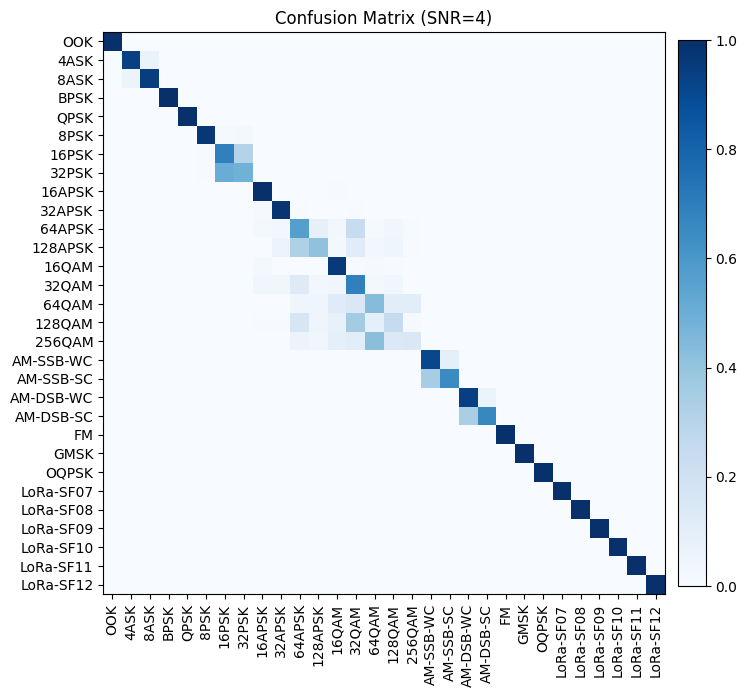

Classification Report for SNR 4 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       0.95      0.93      0.94       410
        8ASK       0.93      0.95      0.94       409
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       410
        8PSK       0.99      0.97      0.98       410
       16PSK       0.57      0.69      0.62       410
       32PSK       0.60      0.49      0.54       410
      16APSK       0.91      1.00      0.95       409
      32APSK       0.88      0.98      0.93       410
      64APSK       0.44      0.56      0.50       410
     128APSK       0.63      0.41      0.50       410
       16QAM       0.72      0.96      0.83       409
       32QAM       0.41      0.69      0.52       409
       64QAM       0.43      0.44      0.43       409
      128QAM       0.40      0.25      0.31       410
      256QAM       0.53      0.14      0.23   

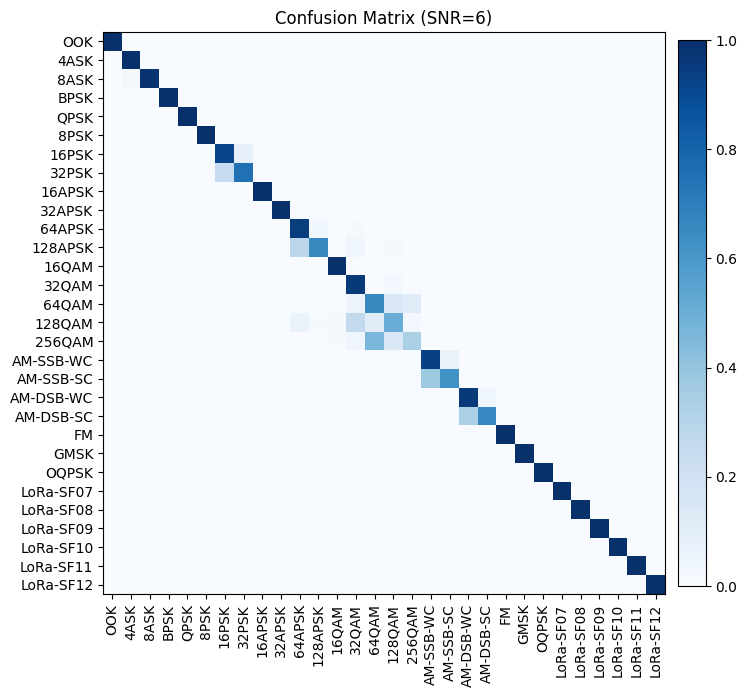

Classification Report for SNR 6 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       0.98      1.00      0.99       409
        8ASK       1.00      0.98      0.99       410
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       410
        8PSK       1.00      1.00      1.00       410
       16PSK       0.79      0.92      0.85       409
       32PSK       0.90      0.75      0.82       410
      16APSK       1.00      1.00      1.00       410
      32APSK       0.99      1.00      1.00       410
      64APSK       0.72      0.95      0.82       410
     128APSK       0.91      0.66      0.77       409
       16QAM       0.97      1.00      0.98       409
       32QAM       0.70      0.96      0.81       409
       64QAM       0.53      0.66      0.59       409
      128QAM       0.60      0.51      0.55       409
      256QAM       0.69      0.33      0.45   

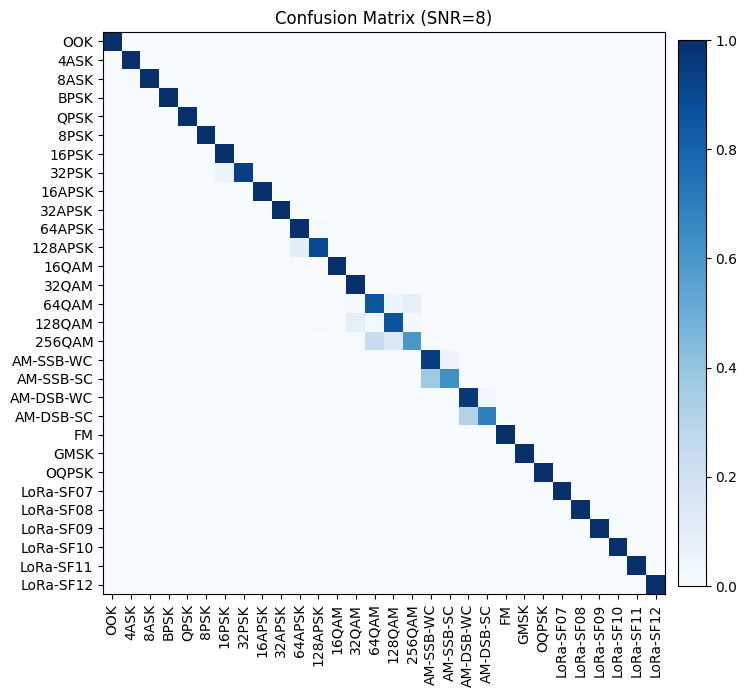

Classification Report for SNR 8 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       1.00      1.00      1.00       409
        8ASK       1.00      1.00      1.00       409
        BPSK       1.00      1.00      1.00       409
        QPSK       1.00      1.00      1.00       409
        8PSK       1.00      1.00      1.00       409
       16PSK       0.94      1.00      0.97       409
       32PSK       0.99      0.94      0.97       409
      16APSK       1.00      1.00      1.00       409
      32APSK       1.00      1.00      1.00       409
      64APSK       0.91      1.00      0.95       409
     128APSK       0.99      0.90      0.94       409
       16QAM       1.00      1.00      1.00       410
       32QAM       0.90      1.00      0.95       410
       64QAM       0.76      0.85      0.81       409
      128QAM       0.81      0.86      0.84       410
      256QAM       0.85      0.60      0.70   

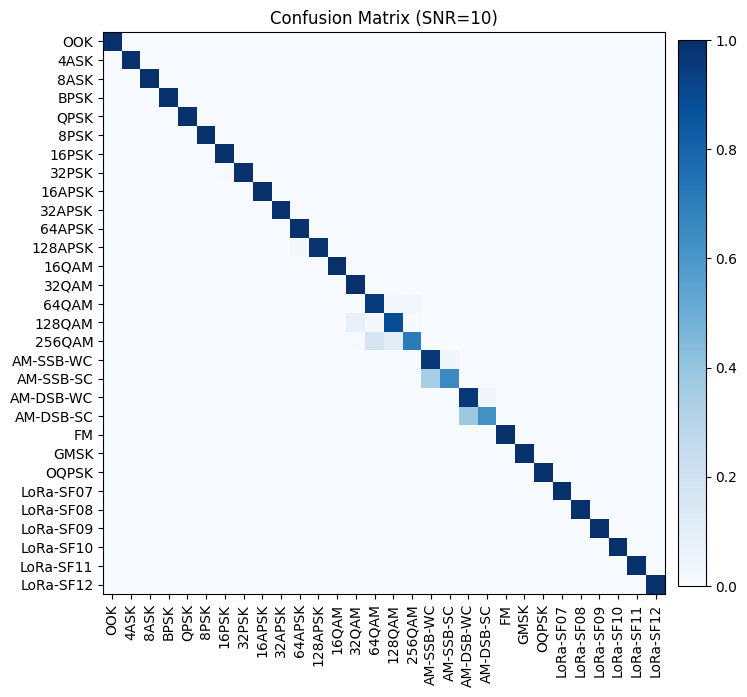

Classification Report for SNR 10 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       409
        4ASK       1.00      1.00      1.00       410
        8ASK       1.00      1.00      1.00       410
        BPSK       1.00      1.00      1.00       409
        QPSK       1.00      1.00      1.00       409
        8PSK       1.00      1.00      1.00       410
       16PSK       0.99      1.00      1.00       410
       32PSK       1.00      0.99      1.00       409
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       409
      64APSK       0.98      1.00      0.99       410
     128APSK       1.00      0.98      0.99       410
       16QAM       1.00      1.00      1.00       409
       32QAM       0.92      1.00      0.96       410
       64QAM       0.83      0.95      0.89       410
      128QAM       0.87      0.89      0.88       410
      256QAM       0.95      0.71      0.81  

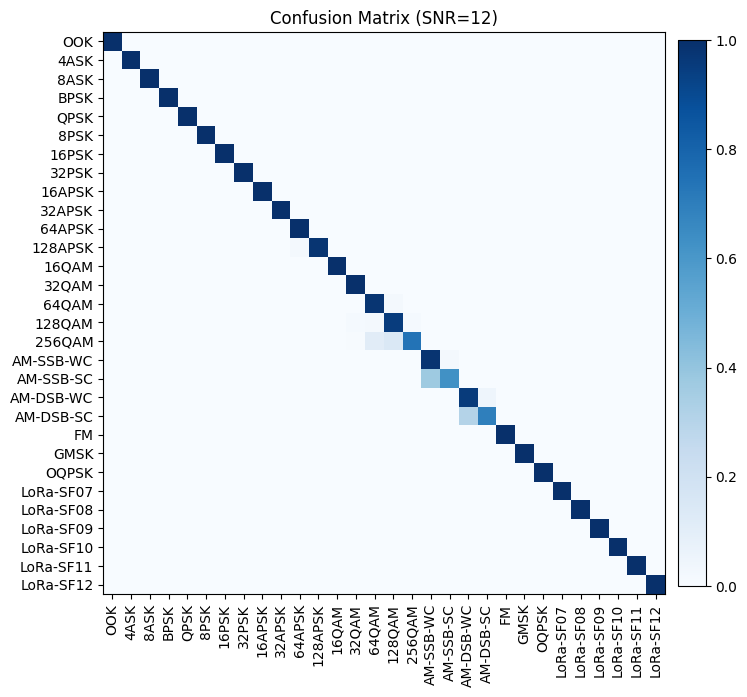

Classification Report for SNR 12 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       409
        4ASK       1.00      1.00      1.00       410
        8ASK       1.00      1.00      1.00       409
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       409
        8PSK       1.00      1.00      1.00       410
       16PSK       1.00      1.00      1.00       409
       32PSK       1.00      1.00      1.00       410
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       410
      64APSK       0.98      1.00      0.99       410
     128APSK       1.00      0.98      0.99       409
       16QAM       1.00      1.00      1.00       410
       32QAM       0.98      1.00      0.99       409
       64QAM       0.88      0.98      0.93       410
      128QAM       0.85      0.95      0.90       409
      256QAM       0.98      0.74      0.84  

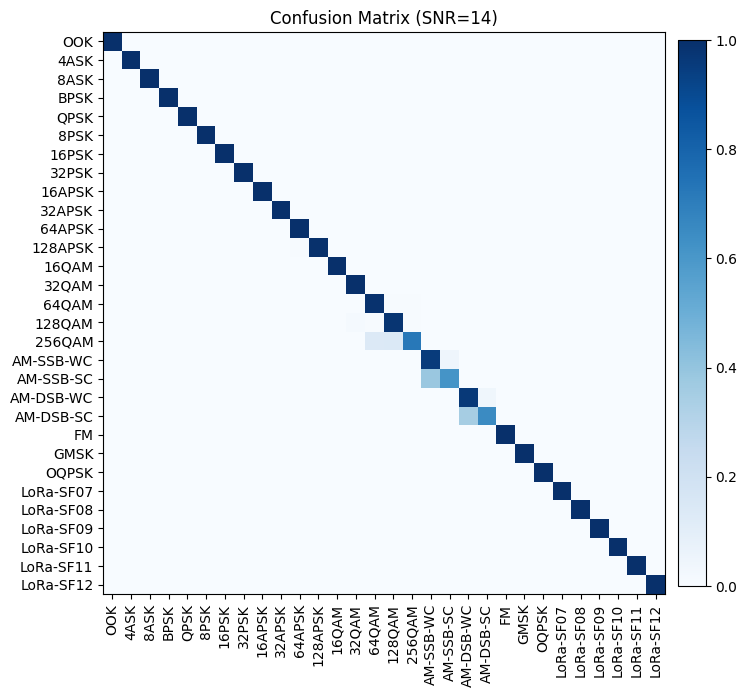

Classification Report for SNR 14 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       1.00      1.00      1.00       409
        8ASK       1.00      1.00      1.00       410
        BPSK       1.00      1.00      1.00       409
        QPSK       1.00      1.00      1.00       410
        8PSK       1.00      1.00      1.00       410
       16PSK       1.00      1.00      1.00       410
       32PSK       1.00      1.00      1.00       410
      16APSK       1.00      1.00      1.00       409
      32APSK       1.00      1.00      1.00       410
      64APSK       0.99      1.00      1.00       409
     128APSK       1.00      0.99      1.00       410
       16QAM       1.00      1.00      1.00       410
       32QAM       0.99      1.00      0.99       410
       64QAM       0.88      0.99      0.93       410
      128QAM       0.87      0.98      0.92       409
      256QAM       0.99      0.72      0.83  

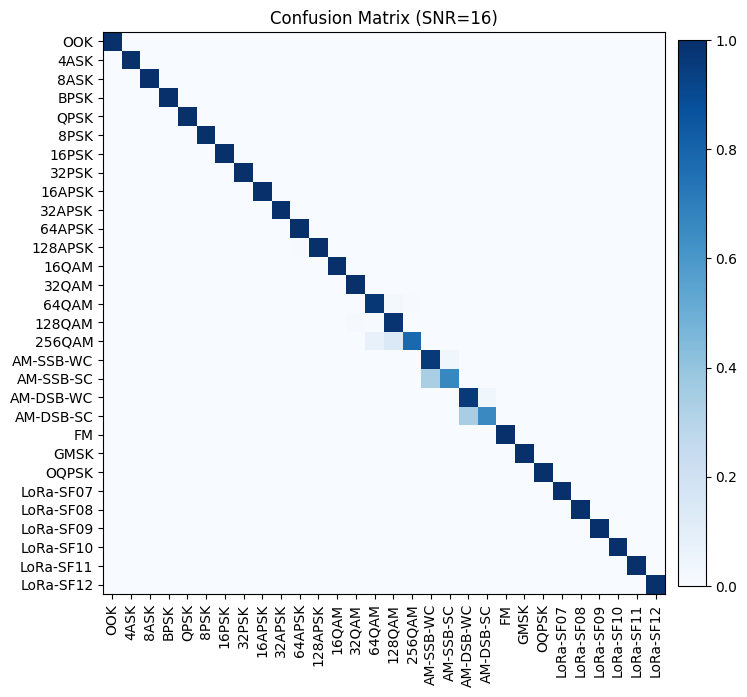

Classification Report for SNR 16 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       409
        4ASK       1.00      1.00      1.00       409
        8ASK       1.00      1.00      1.00       410
        BPSK       1.00      1.00      1.00       409
        QPSK       1.00      1.00      1.00       410
        8PSK       1.00      1.00      1.00       409
       16PSK       1.00      1.00      1.00       409
       32PSK       1.00      1.00      1.00       410
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       410
      64APSK       0.99      1.00      1.00       410
     128APSK       1.00      0.99      1.00       409
       16QAM       1.00      1.00      1.00       410
       32QAM       0.99      1.00      0.99       410
       64QAM       0.92      0.97      0.95       410
      128QAM       0.86      0.98      0.92       409
      256QAM       0.99      0.78      0.87  

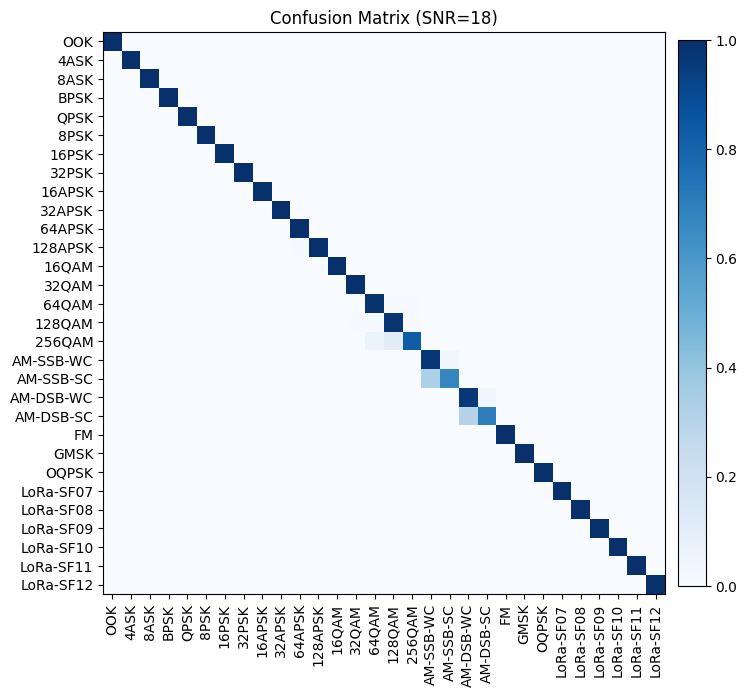

Classification Report for SNR 18 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       409
        4ASK       1.00      1.00      1.00       410
        8ASK       1.00      1.00      1.00       410
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       409
        8PSK       1.00      1.00      1.00       410
       16PSK       1.00      1.00      1.00       409
       32PSK       1.00      1.00      1.00       410
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       410
      64APSK       0.99      1.00      1.00       410
     128APSK       1.00      0.99      1.00       409
       16QAM       1.00      1.00      1.00       410
       32QAM       0.99      1.00      1.00       410
       64QAM       0.94      0.99      0.96       409
      128QAM       0.89      0.98      0.93       410
      256QAM       0.99      0.83      0.90  

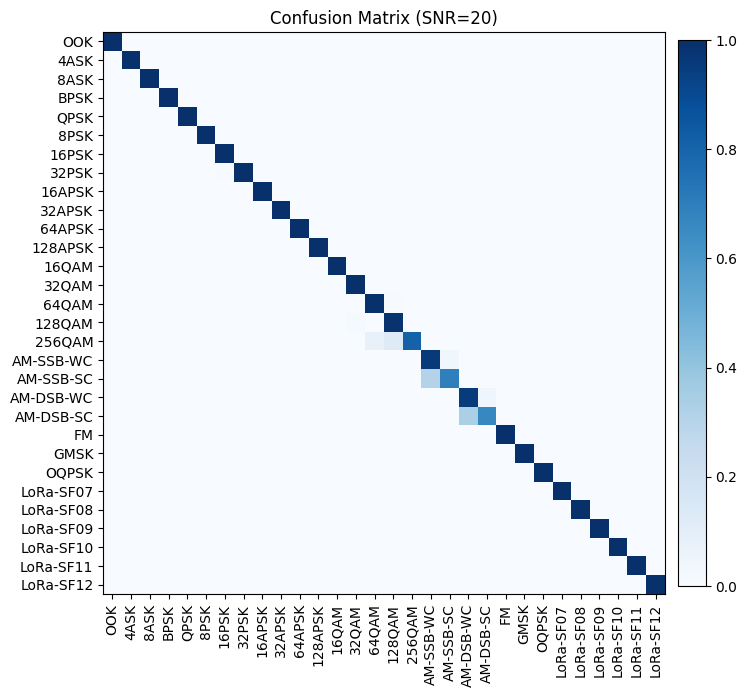

Classification Report for SNR 20 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       1.00      1.00      1.00       409
        8ASK       1.00      1.00      1.00       409
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       410
        8PSK       1.00      1.00      1.00       409
       16PSK       1.00      1.00      1.00       410
       32PSK       1.00      1.00      1.00       409
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       410
      64APSK       1.00      1.00      1.00       409
     128APSK       1.00      1.00      1.00       409
       16QAM       1.00      1.00      1.00       410
       32QAM       0.99      1.00      0.99       410
       64QAM       0.93      0.99      0.96       410
      128QAM       0.88      0.99      0.93       409
      256QAM       1.00      0.80      0.89  

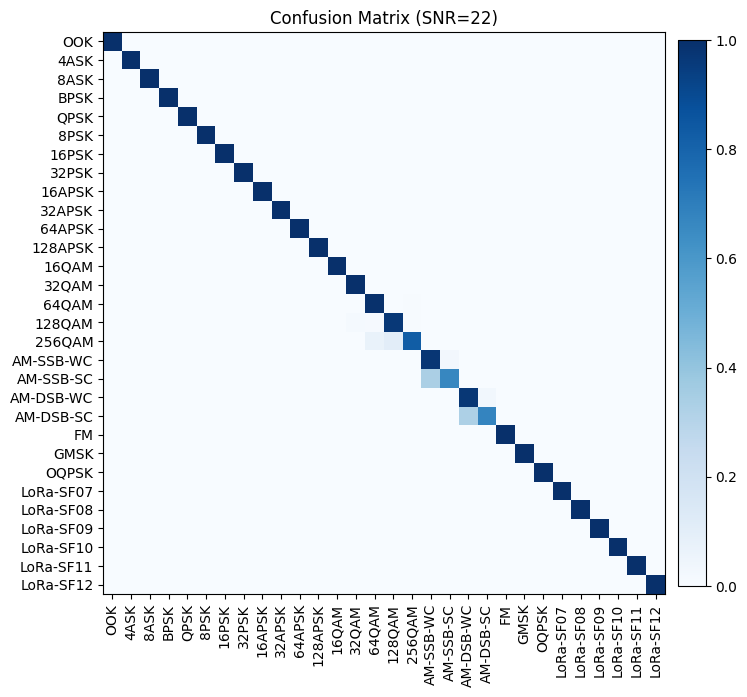

Classification Report for SNR 22 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       1.00      1.00      1.00       409
        8ASK       1.00      1.00      1.00       410
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       410
        8PSK       1.00      1.00      1.00       409
       16PSK       1.00      1.00      1.00       410
       32PSK       1.00      1.00      1.00       410
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       410
      64APSK       1.00      1.00      1.00       410
     128APSK       1.00      1.00      1.00       409
       16QAM       1.00      1.00      1.00       410
       32QAM       0.98      1.00      0.99       409
       64QAM       0.93      0.99      0.96       410
      128QAM       0.90      0.97      0.93       410
      256QAM       0.99      0.83      0.90  

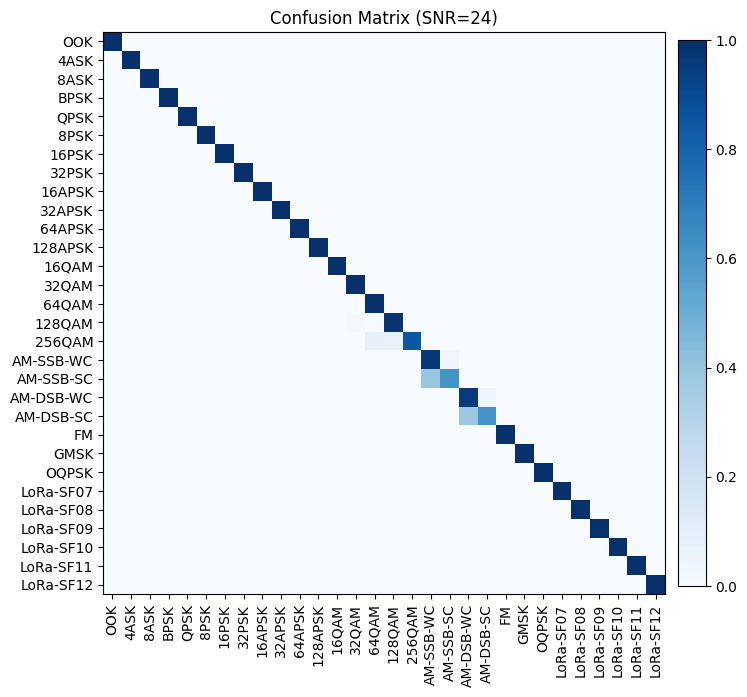

Classification Report for SNR 24 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       1.00      1.00      1.00       409
        8ASK       1.00      1.00      1.00       410
        BPSK       1.00      1.00      1.00       409
        QPSK       1.00      1.00      1.00       409
        8PSK       1.00      1.00      1.00       409
       16PSK       1.00      1.00      1.00       410
       32PSK       1.00      1.00      1.00       410
      16APSK       1.00      1.00      1.00       409
      32APSK       1.00      1.00      1.00       409
      64APSK       1.00      1.00      1.00       410
     128APSK       1.00      1.00      1.00       410
       16QAM       1.00      1.00      1.00       410
       32QAM       0.99      1.00      0.99       410
       64QAM       0.92      1.00      0.96       409
      128QAM       0.93      0.98      0.95       410
      256QAM       0.99      0.85      0.92  

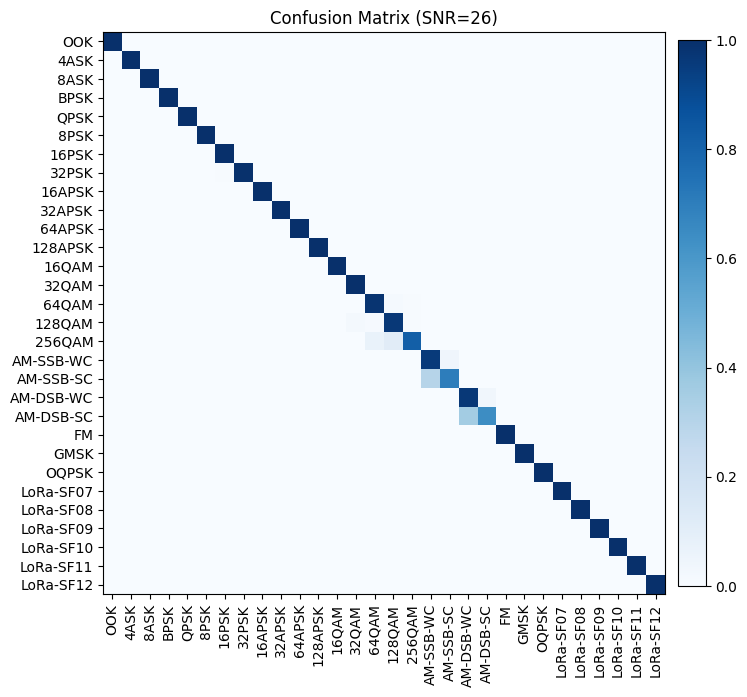

Classification Report for SNR 26 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       1.00      1.00      1.00       410
        8ASK       1.00      1.00      1.00       410
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       410
        8PSK       1.00      1.00      1.00       410
       16PSK       1.00      1.00      1.00       410
       32PSK       1.00      1.00      1.00       409
      16APSK       1.00      1.00      1.00       409
      32APSK       1.00      1.00      1.00       409
      64APSK       1.00      1.00      1.00       410
     128APSK       1.00      1.00      1.00       410
       16QAM       1.00      1.00      1.00       409
       32QAM       0.98      1.00      0.99       410
       64QAM       0.93      0.98      0.95       410
      128QAM       0.89      0.97      0.93       409
      256QAM       0.99      0.82      0.90  

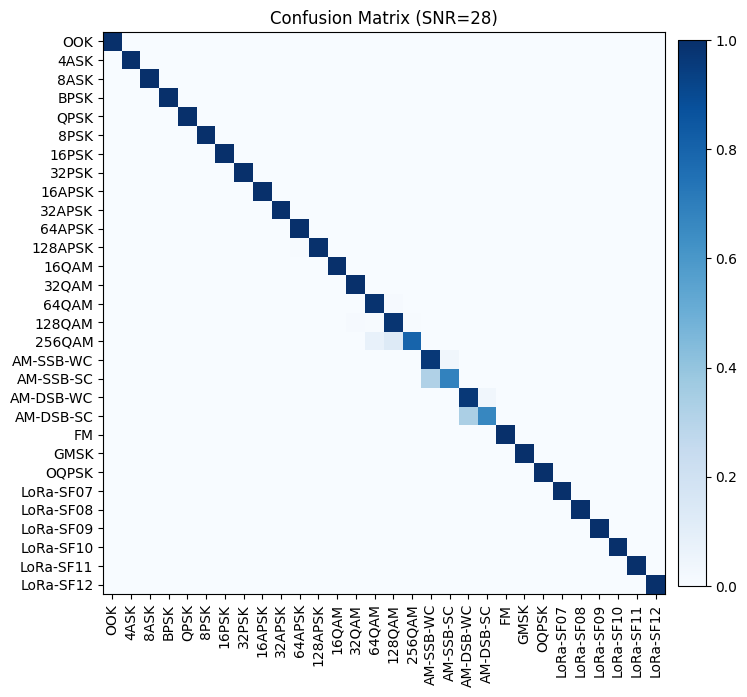

Classification Report for SNR 28 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       409
        4ASK       1.00      1.00      1.00       410
        8ASK       1.00      1.00      1.00       409
        BPSK       1.00      1.00      1.00       409
        QPSK       1.00      1.00      1.00       410
        8PSK       1.00      1.00      1.00       410
       16PSK       1.00      1.00      1.00       410
       32PSK       1.00      1.00      1.00       409
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       410
      64APSK       1.00      1.00      1.00       410
     128APSK       1.00      1.00      1.00       409
       16QAM       1.00      1.00      1.00       410
       32QAM       0.99      1.00      0.99       410
       64QAM       0.93      0.99      0.96       410
      128QAM       0.88      0.98      0.93       409
      256QAM       0.99      0.80      0.88  

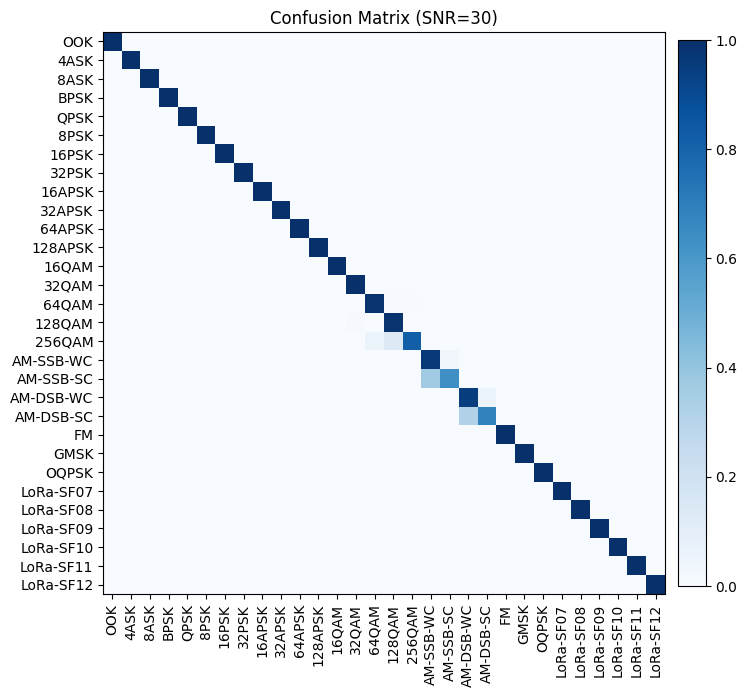

Classification Report for SNR 30 dB
              precision    recall  f1-score   support

         OOK       1.00      1.00      1.00       410
        4ASK       1.00      1.00      1.00       409
        8ASK       1.00      1.00      1.00       409
        BPSK       1.00      1.00      1.00       410
        QPSK       1.00      1.00      1.00       409
        8PSK       1.00      1.00      1.00       410
       16PSK       1.00      1.00      1.00       409
       32PSK       1.00      1.00      1.00       409
      16APSK       1.00      1.00      1.00       410
      32APSK       1.00      1.00      1.00       409
      64APSK       1.00      1.00      1.00       410
     128APSK       1.00      1.00      1.00       409
       16QAM       1.00      1.00      1.00       409
       32QAM       0.99      1.00      0.99       410
       64QAM       0.95      0.99      0.97       410
      128QAM       0.88      0.99      0.93       409
      256QAM       0.99      0.82      0.90  

In [40]:
#resnet18
from src.evaluate import evaluate_model_by_snr
path = './Resnet18_1024_RadioML2018_plus_LoRa.keras'
results = evaluate_model_by_snr(model_path=path,
                                class_labels=classes,
                                snr_values=RadioMLConfig.SNR_RANGE,
                                data_gen=test_ds,
                                X_test=X_test,
                                Y_test=Y_test,
                                snr_test=Z_test,
                                show_report=True)

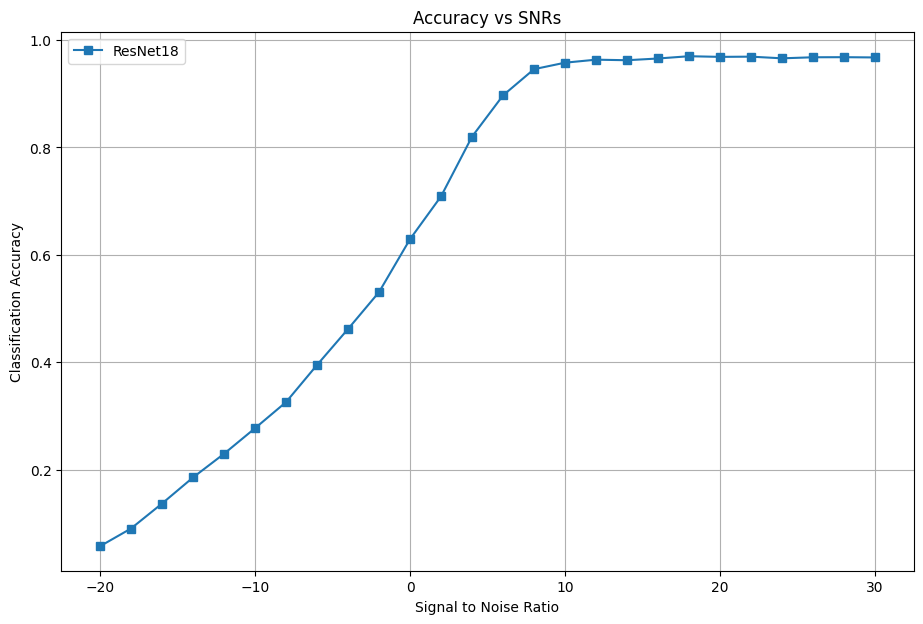

In [44]:
from src.evaluate import plot_accuracy_vs_snr
plot_accuracy_vs_snr(snr_values=RadioMLConfig.SNR_RANGE, 
                     accuracy_values=results,
                     label='ResNet18')

In [38]:
np.save("./results/results_resnet18_combined.npy", results)